# 1 — Imports & Setup

In [ ]:
import sys, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import torch
import torch.nn as nn
from torch.cuda.amp import GradScaler, autocast
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)

# Auto-detect project root
root = Path.cwd()
while not (root / 'Pipeline_').exists() and root != root.parent:
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from Pipeline_.preprocessor import WaRPPreprocessor
from Models.ResNet50 import ResNet50

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")

torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)


Device  : cuda
PyTorch : 2.11.0+cu130


# 2 — Hyperparameters (Baseline)

In [3]:
EPOCHS       = 40
BATCH_SIZE   = 16
LR           = 1e-4
WEIGHT_DECAY = 1e-4
DROPOUT      = 0.4
NUM_CLASSES  = 28

print(f"Epochs      : {EPOCHS}")
print(f"Batch size  : {BATCH_SIZE}")
print(f"LR          : {LR}")
print(f"Dropout     : {DROPOUT}")

Epochs      : 40
Batch size  : 16
LR          : 0.0001
Dropout     : 0.4


# 3 — Data Pipeline (WaRP‑C Baseline)
 Uses the pretrained CNN augmentation:
 PadToSquare
 RandomResizedCrop(0.6–1.0)
 flips
 rotations
 ColorJitter
 GaussianBlur
 RandomErasing
 WaRP‑C mean/std
 WeightedRandomSampler
 minority augmentation

In [4]:
pp = WaRPPreprocessor(
    raw_root       = root / "Dataset/raw/WaRP-C",
    processed_root = root / "Dataset/processed",
    stats_file     = root / "Dataset/dataset_stats.json",
    batch_size     = BATCH_SIZE,
    num_workers    = 4,
)

train_loader, test_loader = pp.get_loaders(model_type="resnet")

CLASS_NAMES = sorted(
    d.name for d in (root / "Dataset/processed/train").iterdir() if d.is_dir()
)

print(f"Classes       : {len(CLASS_NAMES)}")
print(f"Train batches : {len(train_loader)}")
print(f"Test  batches : {len(test_loader)}")


[get_loaders] model='resnet'
  sampler=True  minority_aug=True  mixup=False  pipeline='pretrained_cnn'
  train=547 batches  test=97 batches  sampler=WeightedRandom
Classes       : 28
Train batches : 547
Test  batches : 97


# 4 — Loss Function

In [5]:
class_weights = pp.get_class_weights(device=DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)
print("Loss: CrossEntropyLoss + class weights")

Loss: CrossEntropyLoss + class weights


# 5 — Model (ResNet‑50 Baseline)

In [6]:
model = ResNet50(
    num_classes = NUM_CLASSES,
    dropout     = DROPOUT,
).to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = LR,
    weight_decay = WEIGHT_DECAY,
)

scaler = GradScaler(enabled=(DEVICE == "cuda"))

# Sanity check
with torch.no_grad():
    out = model(torch.zeros(2, 3, 384, 384).to(DEVICE))
print("Output shape:", out.shape)

C:\Users\scott\AppData\Local\Temp\ipykernel_14956\3376850436.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(DEVICE == "cuda"))


Output shape: torch.Size([2, 28])


# 6 — Training Loop

In [7]:
train_losses, train_accs, test_accs = [], [], []
best_acc = 0.0

print(f"Starting {EPOCHS} epochs...\n")

for epoch in range(1, EPOCHS + 1):

    model.train()
    ep_loss = correct = total = 0
    t0 = time.time()

    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)

        optimizer.zero_grad()

        with autocast(enabled=(DEVICE == "cuda")):
            logits = model(imgs)
            loss   = criterion(logits, lbls)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        ep_loss += loss.item()
        correct += (logits.argmax(1) == lbls).sum().item()
        total   += lbls.size(0)

    train_loss = ep_loss / len(train_loader)
    train_acc  = correct / total * 100

    # Evaluate
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, lbls in test_loader:
            preds = model(imgs.to(DEVICE)).argmax(1).cpu()
            correct += (preds == lbls).sum().item()
            total   += lbls.size(0)
    test_acc = correct / total * 100

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), root / "Models/weights/resnet50_baseline.pth")
        flag = " ← best"
    else:
        flag = ""

    print(f"Epoch {epoch:3d}/{EPOCHS} | "
          f"loss={train_loss:.4f} | train={train_acc:.2f}% | "
          f"test={test_acc:.2f}% | best={best_acc:.2f}% | "
          f"{time.time()-t0:.1f}s{flag}")


Starting 40 epochs...



C:\Users\scott\AppData\Local\Temp\ipykernel_14956\1182482516.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == "cuda")):


Epoch   1/40 | loss=2.8223 | train=6.67% | test=6.19% | best=6.19% | 22.6s ← best
Epoch   2/40 | loss=2.2706 | train=18.32% | test=11.67% | best=11.67% | 8.2s ← best
Epoch   3/40 | loss=1.9603 | train=24.87% | test=16.18% | best=16.18% | 8.2s ← best
Epoch   4/40 | loss=1.7618 | train=30.22% | test=18.31% | best=18.31% | 8.0s ← best
Epoch   5/40 | loss=1.5994 | train=33.92% | test=20.50% | best=20.50% | 8.1s ← best
Epoch   6/40 | loss=1.5736 | train=35.33% | test=24.11% | best=24.11% | 8.0s ← best
Epoch   7/40 | loss=1.4633 | train=38.62% | test=26.24% | best=26.24% | 8.0s ← best
Epoch   8/40 | loss=1.4053 | train=40.47% | test=26.69% | best=26.69% | 7.9s ← best
Epoch   9/40 | loss=1.3547 | train=42.02% | test=27.27% | best=27.27% | 7.9s ← best
Epoch  10/40 | loss=1.2949 | train=43.27% | test=30.17% | best=30.17% | 7.9s ← best
Epoch  11/40 | loss=1.3060 | train=43.85% | test=32.62% | best=32.62% | 8.1s ← best
Epoch  12/40 | loss=1.2853 | train=44.07% | test=32.82% | best=32.82% | 8.0s ←

# 7 — Training Curves

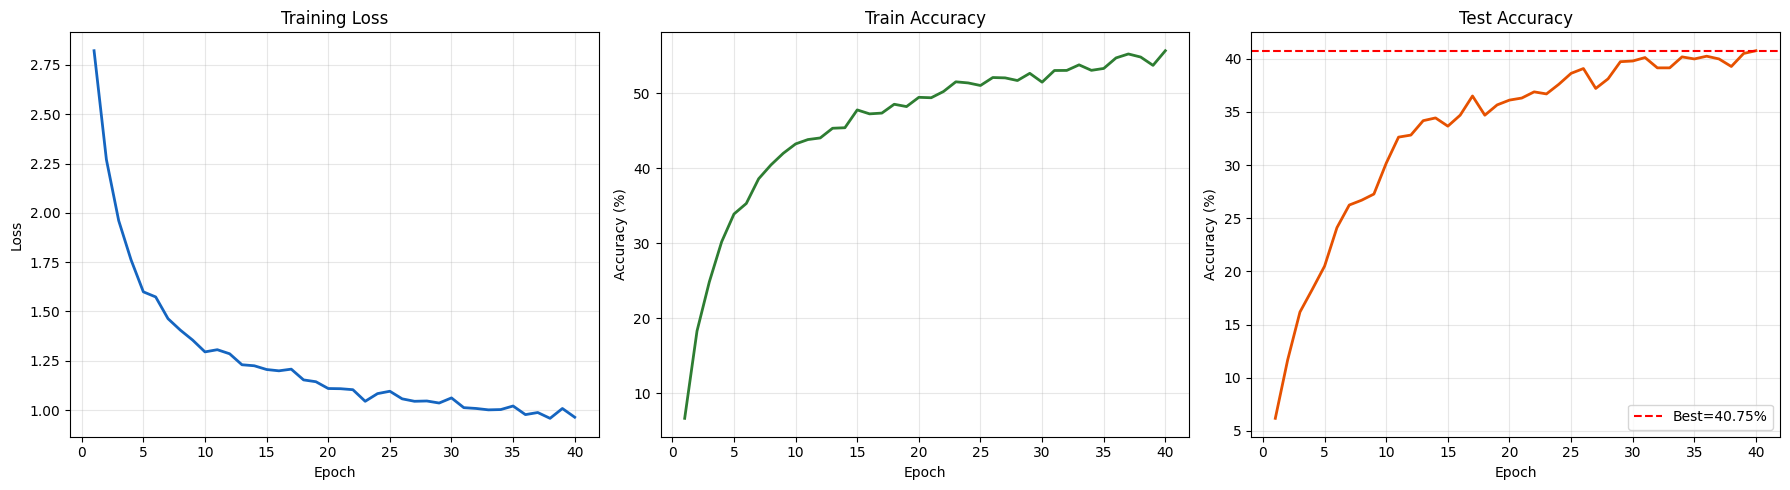

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ep = range(1, EPOCHS + 1)

axes[0].plot(ep, train_losses, "#1565C0", lw=2)
axes[0].set(title="Training Loss", xlabel="Epoch", ylabel="Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(ep, train_accs, "#2E7D32", lw=2)
axes[1].set(title="Train Accuracy", xlabel="Epoch", ylabel="Accuracy (%)")
axes[1].grid(alpha=0.3)

axes[2].plot(ep, test_accs, "#E65100", lw=2)
axes[2].axhline(best_acc, color="red", ls="--", label=f"Best={best_acc:.2f}%")
axes[2].set(title="Test Accuracy", xlabel="Epoch", ylabel="Accuracy (%)")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# 8 — Evaluation (Final Metrics)

In [9]:
model.load_state_dict(torch.load(root / "Models/weights/resnet50_baseline.pth"))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, lbls in test_loader:
        preds = model(imgs.to(DEVICE)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(lbls.numpy())

y_pred = np.array(all_preds)
y_true = np.array(all_labels)

acc  = (y_pred == y_true).mean() * 100
f1   = f1_score(y_true, y_pred, average="macro") * 100
w_f1 = f1_score(y_true, y_pred, average="weighted") * 100
prec = precision_score(y_true, y_pred, average="macro") * 100
rec  = recall_score(y_true, y_pred, average="macro") * 100

print("="*50)
print("  ResNet‑50 Baseline — Final Metrics")
print("="*50)
print(f"  Accuracy      : {acc:.2f}%")
print(f"  Macro F1      : {f1:.2f}%")
print(f"  Weighted F1   : {w_f1:.2f}%")
print(f"  Precision     : {prec:.2f}%")
print(f"  Recall        : {rec:.2f}%")
print("="*50)


  ResNet‑50 Baseline — Final Metrics
  Accuracy      : 40.75%
  Macro F1      : 43.05%
  Weighted F1   : 38.61%
  Precision     : 44.13%
  Recall        : 51.97%


c:\repo\Waste-Classification\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# 9 — Confusion Matrix

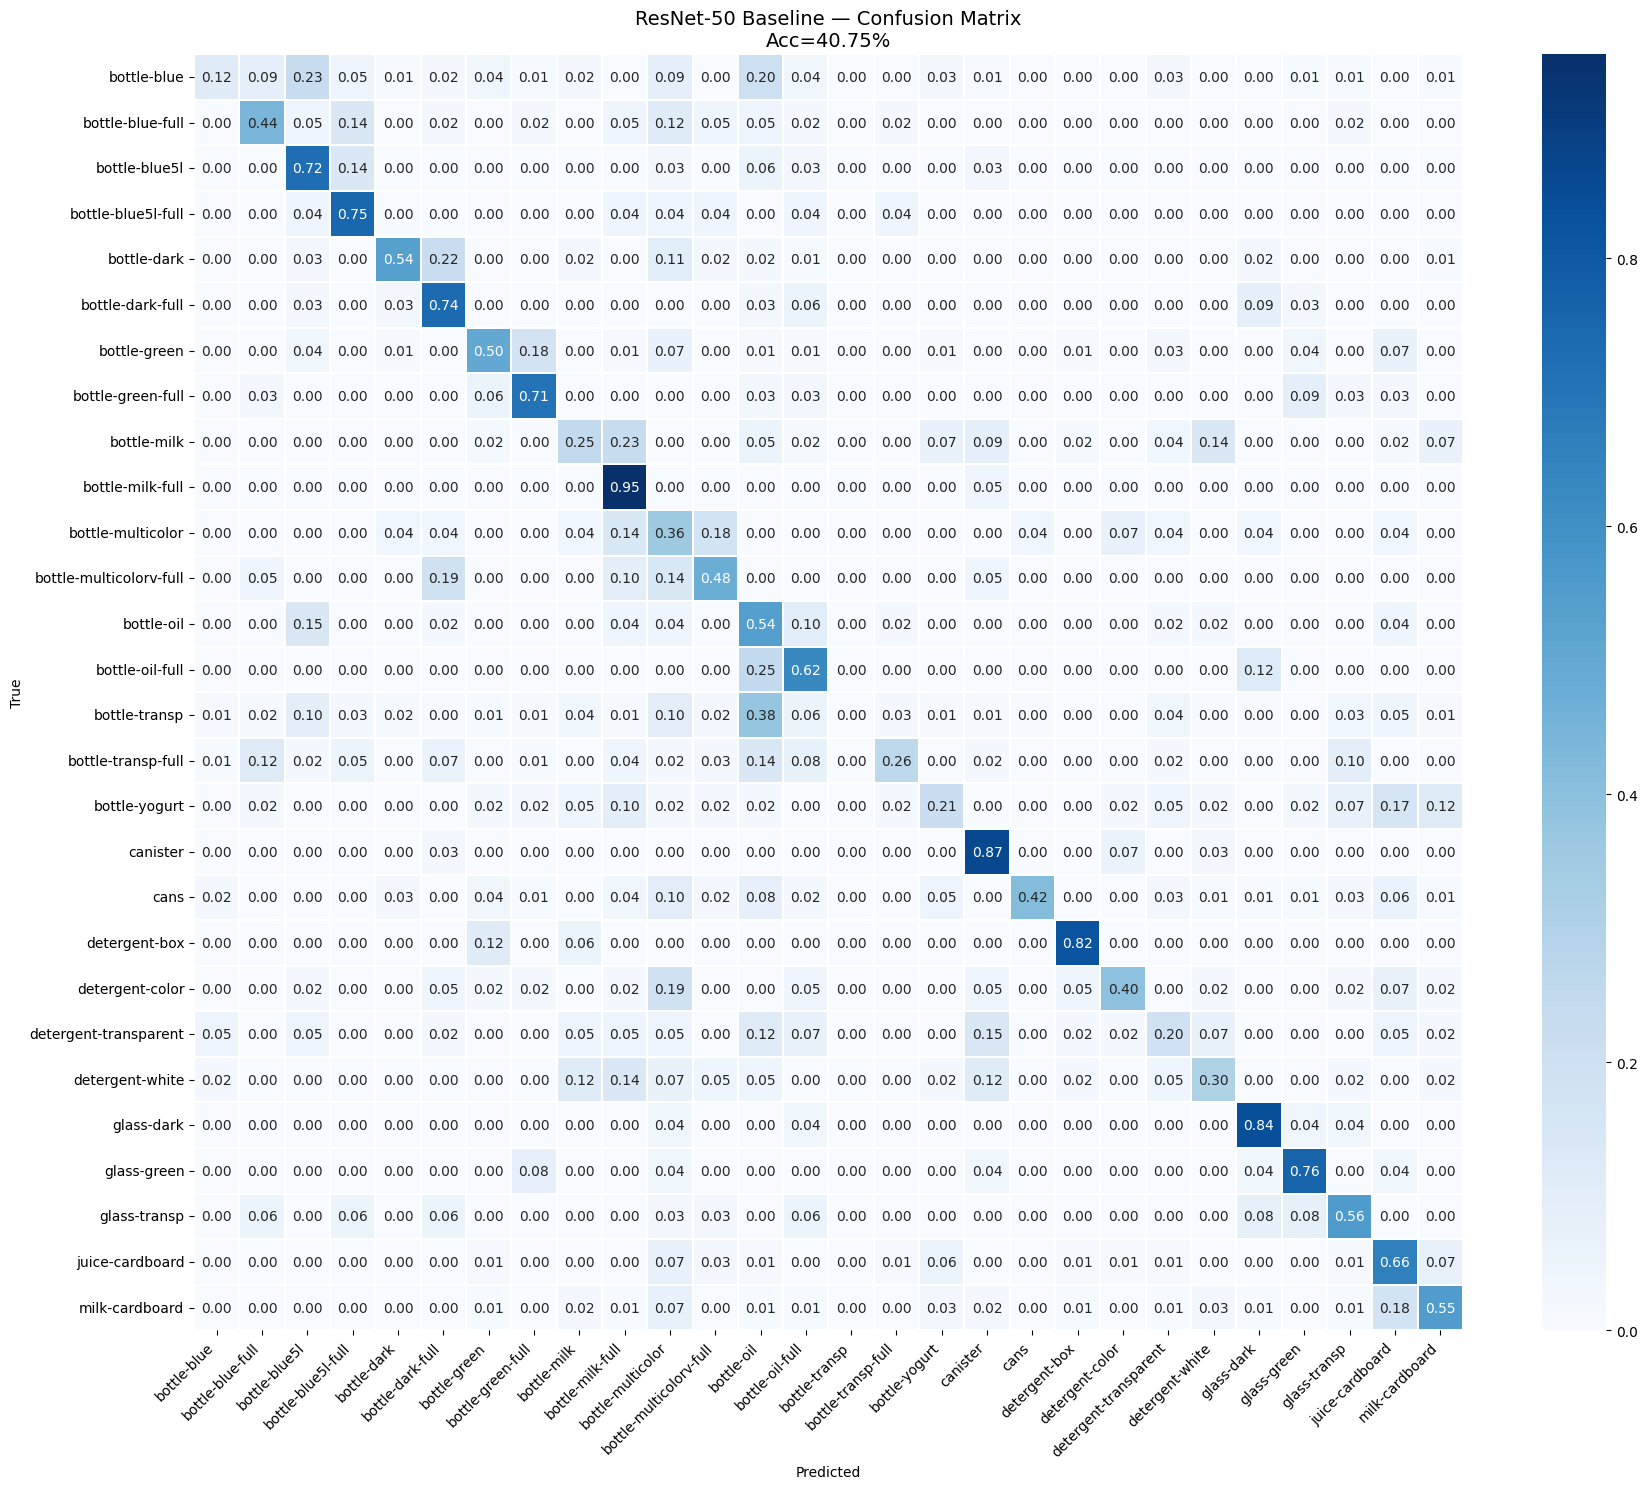

In [12]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(
    cm_norm,
    annot=True,            # ← SHOW VALUES
    fmt=".2f",             # ← FORMAT VALUES
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.3
)
ax.set_title(f"ResNet‑50 Baseline — Confusion Matrix\nAcc={acc:.2f}%", fontsize=14)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# 10 — Summary

In [11]:
print("="*60)
print("  ResNet‑50 Baseline — Summary")
print("="*60)
print(f"  Pretrained       : ImageNet‑1K")
print(f"  Epochs           : {EPOCHS}")
print(f"  Batch size       : {BATCH_SIZE}")
print(f"  LR               : {LR}")
print(f"  Dropout          : {DROPOUT}")
print(f"  Best test acc    : {best_acc:.2f}%")
print(f"  Final accuracy   : {acc:.2f}%")
print(f"  Macro F1         : {f1:.2f}%")
print(f"  Weighted F1      : {w_f1:.2f}%")
print("="*60)


  ResNet‑50 Baseline — Summary
  Pretrained       : ImageNet‑1K
  Epochs           : 40
  Batch size       : 16
  LR               : 0.0001
  Dropout          : 0.4
  Best test acc    : 40.75%
  Final accuracy   : 40.75%
  Macro F1         : 43.05%
  Weighted F1      : 38.61%
